# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0, para carregar o arquivo certo.

In [4]:
CARGO = "GOVERNADOR"   # mesmo valor usado na Fase 0
UF = None               # mesmo valor usado na Fase 0
ANO_ELEICAO = 2026

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_GOVERNADOR_BRASIL_2026.csv  ->  199 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002532492,10,ALAN RICK MIRANDA,ALAN RICK,#NULO,44726570234,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,10,REPUBLICANOS,REPUBLICANOS,-1,#NULO,#NULO,#NULO,10001800116,TRABALHO DA ESPERANÇA,REPUBLICANOS / NOVO / PSD / AVANTE,AC,1976-10-23,3240992410,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,1319000.0,306686.82,162982.34,644253.0,2811645.56,0.00,5244567.72,15.472704,49
1,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002533539,36,FRANCISCO DAS CHAGAS CONCEICAO DA SILVA,DR.LUISINHO,#NULO,48432156272,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,36,AGIR,AGIR,-1,#NULO,#NULO,#NULO,10001800168,PARTIDO ISOLADO,AGIR,AC,1975-01-16,2584592402,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,51
2,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002544015,45,SEBASTIAO BOCALOM RODRIGUES,TIÃO BOCALOM,#NULO,17357152987,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,45,PSDB,PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA,100,FEDERAÇÃO PSDB CIDADANIA,PSDB/CIDADANIA,PSDB/CIDADANIA,10001800730,PRODUZIR PARA EMPREGAR,FEDERAÇÃO RENOVAÇÃO SOLIDÁRIA(PRD/SOLIDARIEDAD...,PR,1953-05-18,2053882488,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,601,AGRICULTOR,-1,#NULO,80000.0,118000.00,8000.00,0.0,0.00,1010500.00,1216500.00,14.011489,73
3,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002544107,11,MAILZA ASSIS CAMELI,MAILZA ASSIS,#NULO,61280178272,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,11,PP,PROGRESSISTAS,104,FEDERAÇÃO UNIÃO PROGRESSISTA,UNIÃO/PP,UNIÃO/PP,10001800654,AVANÇA ACRE,PDT / MDB / PL / DEMOCRATA / FEDERAÇÃO UNIÃO P...,MS,1976-12-10,6765752305,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,274,GOVERNADOR,-1,#NULO,0.0,0.00,0.00,0.0,0.00,167482.91,167482.91,12.028643,49
4,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002549500,21,EUDO RAFFAEL LIMA DA SILVA,EUDO RAFFAEL,#NULO,79365078253,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,21,PCB,PARTIDO COMUNISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,10001801047,PARTIDO ISOLADO,PCB,AC,1985-08-27,4546212402,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),3,PARDA,395,BANCÁRIO E ECONOMIÁRIO,-1,#NULO,165000.0,0.00,0.00,0.0,0.00,0.00,165000.00,12.013707,41


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

199 candidatos x 59 colunas



str        31
int64      20
float64     8
Name: nº de colunas, dtype: int64

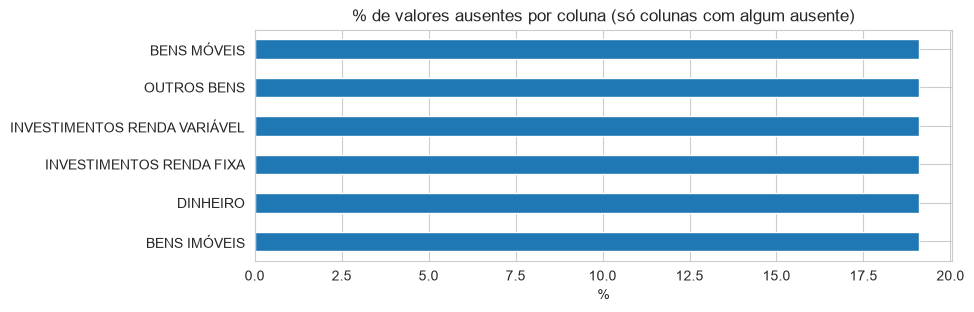

In [6]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [8]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,NR_TURNO
6,CD_ELEICAO
7,DS_ELEICAO
8,DT_ELEICAO
9,TP_ABRANGENCIA


In [ ]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

## 3) Variáveis numéricas: distribuição e outliers

In [ ]:
display(df[colunas_numericas].describe().T)

In [ ]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [ ]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

## 4) Variáveis categóricas: contagens e proporções

In [ ]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

In [ ]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

In [ ]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_SIT_TOT_TURNO'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Situação eleitoral por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_SIT_TOT_TURNO'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Situação eleitoral por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_SIT_TOT_TURNO', y='IDADE', ax=axes[1])
axes[1].set_title('Idade por situação eleitoral')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Esta seção só roda na visão **Brasil** (quando `UF = None`) — não se aplica ao recorte por estado.

In [ ]:
if UF is None:
    resumo_uf = df.groupby('SG_UF').agg(
        qtd_candidatos=('SQ_CANDIDATO', 'count'),
        idade_media=('IDADE', 'mean'),
        patrimonio_mediano=('Total_Bens', 'median'),
        pct_feminino=('DS_GENERO', lambda x: (x == 'FEMININO').mean() * 100),
    ).round(1).sort_values('qtd_candidatos', ascending=False)

    display(resumo_uf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    resumo_uf['qtd_candidatos'].sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'Nº de candidatos a {CARGO} por UF')

    resumo_uf['patrimonio_mediano'].sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
    axes[1].set_title('Patrimônio mediano por UF (R$)')

    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

---
## Fechamento

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.